# 3. Symbolic Framwork
Casadi use **compressed column storage** to store matrics

## 3.1 The SX symbolics

In [9]:
from casadi import *

x = SX.sym('x')
x

SX(x)

In [10]:
x2 = SX.sym('x')
x2

SX(x)

In [ ]:
# x and x2 have the same name, but they are different symbolic variables.
print(x+x2)

(x+x)


In [15]:
# vector and matrix
y = SX.sym('y', 5)
z = SX.sym('z', 4, 2)
y, z

(SX([y_0, y_1, y_2, y_3, y_4]),
 SX(
 [[z_0, z_4], 
  [z_1, z_5], 
  [z_2, z_6], 
  [z_3, z_7]]))

In [17]:
# SX instances can form expressions
f = x**2 + 3*x + 2
f = sqrt(f)
f   

SX(sqrt(((sq(x)+(3*x))+2)))

In [22]:
# Constaant SX instances
B1 = SX.zeros(4, 5) # dense matrix
B2 = SX(4,5) # sparse matrix
B3 = SX.eye(4) # sparse identity matrix
B1, B2, B3

(SX(@1=0, 
 [[@1, @1, @1, @1, @1], 
  [@1, @1, @1, @1, @1], 
  [@1, @1, @1, @1, @1], 
  [@1, @1, @1, @1, @1]]),
 SX(
 [[00, 00, 00, 00, 00], 
  [00, 00, 00, 00, 00], 
  [00, 00, 00, 00, 00], 
  [00, 00, 00, 00, 00]]),
 SX(@1=1, 
 [[@1, 00, 00, 00], 
  [00, @1, 00, 00], 
  [00, 00, @1, 00], 
  [00, 00, 00, @1]]))

In [ ]:
A = SX([[1,2],[3,4]])
B = repmat(SX(1), 2, 2) # create a 2x2 matrix filled with 1s, dense by default

C = np.array([[1,2],[3,4]])
C = SX(C)

A, B, C

(SX(
 [[1, 2], 
  [3, 4]]),
 SX(@1=1, 
 [[@1, @1], 
  [@1, @1]]),
 SX(
 [[1, 2], 
  [3, 4]]))

## 3.2 DM
Nonezero elements are numerical values, not symbolic expressions

In [28]:
C = DM(2,3)
C_dense = C.full()
C, C_dense

(DM(
 [[00, 00, 00], 
  [00, 00, 00]]),
 array([[0., 0., 0.],
        [0., 0., 0.]]))

In [29]:
C_array = np.array(C)
print(np.equal(C_array, C_dense))

[[ True  True  True]
 [ True  True  True]]


In [30]:
from scipy.sparse import csc_matrix
C_sparse = C.sparse()
C_sci_sparse = csc_matrix(C)
C_sparse, C_sci_sparse

(<Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 0 stored elements and shape (2, 3)>,
 <Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 0 stored elements and shape (2, 3)>)

## 3.3 The MX symbolics

In [31]:
# SX expresions, restrict to unary and binary operations
x = SX.sym('x', 2, 2)
y = SX.sym('y')
f = 3*x + y
print(f)
print(f.shape)
print(f[0,0])

@1=3, 
[[((@1*x_0)+y), ((@1*x_2)+y)], 
 [((@1*x_1)+y), ((@1*x_3)+y)]]
(2, 2)
((3*x_0)+y)


In [ ]:
# MX, not restricted to unary and binary operations, and input and output can be matrixes
x = MX.sym('x', 2, 2)
y = MX.sym('y')
f = 3*x + y
print(f)
print(f.shape)
print(f[0,0])

((3*x)+y)
(2, 2)
((3*x)+y)[0]


In [33]:
# set MX elements
x = MX.sym('x', 2)
A = MX(2,2)
A[0,0] = x[0]
A[1,1] = x[1] + x[0]
print("A = ", A)

A =  (project((zeros(2x2,1nz)[0] = x[0]))[1] = (x[1]+x[0]))


In [ ]:
# Sparity and matrix multiplication
M = SX([[3,7],[4,5]])
print(M)
M[0,:] = 1
print(M)
M[2]= 2 # from upper left, to lower right, column-wise
print(M)


[[3, 7], 
 [4, 5]]
@1=1, 
[[@1, @1], 
 [4, 5]]

[[1, 2], 
 [4, 5]]


In [ ]:
# Slice copies the data, not a view, so it can be assigned to.
M1 = M[0,:]
M1[:] = 1
print("M = ", M)
print("M1 = ", M1)


[[1, 2], 
 [4, 5]]
@1=1, [[@1, @1]]


In [ ]:
# list access; not as fast as slice
M = SX([[3,7,8,9],[4,5,6,1]])
print(M)
print(M[0,[0,3]])

print(M[[5,-6]]) # from upper left, to lower right, column-wise


[[3, 7, 8, 9], 
 [4, 5, 6, 1]]
[[3, 9]]
[6, 7]


## 3.6 Arithmetic operations

In [45]:
x = SX.sym('x')
y = SX.sym('y', 2,2)
print(x)
print(y)
f = sin(y) - x
print(f)
print(y*y)
print(y@y)
print(y.T)

x

[[y_0, y_2], 
 [y_1, y_3]]

[[(sin(y_0)-x), (sin(y_2)-x)], 
 [(sin(y_1)-x), (sin(y_3)-x)]]

[[sq(y_0), sq(y_2)], 
 [sq(y_1), sq(y_3)]]

[[(sq(y_0)+(y_2*y_1)), ((y_0*y_2)+(y_2*y_3))], 
 [((y_1*y_0)+(y_3*y_1)), ((y_1*y_2)+sq(y_3))]]

[[y_0, y_1], 
 [y_2, y_3]]


In [46]:
# reshape
x = SX.eye(4)
print(reshape(x, 2, 8))

@1=1, 
[[@1, 00, 00, 00, 00, @1, 00, 00], 
 [00, 00, @1, 00, 00, 00, 00, @1]]


In [50]:
# Concatenate
x = SX.sym('x', 5)
y = SX.sym('y', 5)
print(x)
print(y)
v_conc = vertcat(x,y)
print(v_conc)
print(v_conc.shape)
print(horzcat(x,y))

[x_0, x_1, x_2, x_3, x_4]
[y_0, y_1, y_2, y_3, y_4]
[x_0, x_1, x_2, x_3, x_4, y_0, y_1, y_2, y_3, y_4]
(10, 1)

[[x_0, y_0], 
 [x_1, y_1], 
 [x_2, y_2], 
 [x_3, y_3], 
 [x_4, y_4]]


In [ ]:
# Split
x = SX.sym('x', 5,2)
print(x)
w = horzsplit(x, [0,1,2])
print(w)
print("shape of horzsplit: ", w[0].shape, w[1].shape)
print(w[0], w[1])
w = vertsplit(x, [0,3,5]) # why just use 3, and set first and the last index to default value?
print("shape of vertsplit: ", w[0].shape, w[1].shape)
print(w[0], w[1])
# slice could also be used to split, and only in MX, split functions are more efficient.


[[x_0, x_5], 
 [x_1, x_6], 
 [x_2, x_7], 
 [x_3, x_8], 
 [x_4, x_9]]
[SX([x_0, x_1, x_2, x_3, x_4]), SX([x_5, x_6, x_7, x_8, x_9])]
shape of horzsplit:  (5, 1) (5, 1)
[x_0, x_1, x_2, x_3, x_4] [x_5, x_6, x_7, x_8, x_9]
shape of vertsplit:  (3, 2) (2, 2)

[[x_0, x_5], 
 [x_1, x_6], 
 [x_2, x_7]] 
[[x_3, x_8], 
 [x_4, x_9]]


## 3.8 Linear algtebra

In [58]:
A = MX.sym('A', 3, 3)
b = MX.sym('b', 3)
x = solve(A,b)
print(x)

(A\b)


## 3.9 Calculus
- Forward mode: N < M, given input change direction vector to see how the output change. 
$$
\hat{y} = \frac{\partial{f}}{\partial{x}} \hat{x}
$$

- Reverse mode, Jacobian-transposed-times-vector
$$
g(x) = \bar{y}f(x) \\

\nabla_{x}g = J^T \bar{y} \\

\bar{x} = (\frac{\partial{f}} {\partial{x}})^T \bar{y}
$$
To see how much each entry in x effects the result in direction $\bar{y}$; this is used in backpropagation in dl, and in optimization problem, since the objective function are mostly return scalar.

In [ ]:
# Jacobian and gradient always return a dense vector
A = SX.sym('A', 3, 2)
x = SX.sym('x', 2)
y = A @ x
print(y)
print(y.shape)
J = jacobian(y,x)
print(J)
print(J.shape)

[((A_0*x_0)+(A_3*x_1)), ((A_1*x_0)+(A_4*x_1)), ((A_2*x_0)+(A_5*x_1))]
(3, 1)

[[A_0, A_3], 
 [A_1, A_4], 
 [A_2, A_5]]
(3, 2)


In [ ]:
dot_A = dot(A,A)
print(dot_A)
print(dot_A.shape)
grad = gradient(dot_A,A)
print(grad)
print(grad.shape)

(((((sq(A_0)+sq(A_1))+sq(A_2))+sq(A_3))+sq(A_4))+sq(A_5))
(1, 1)

[[(A_0+A_0), (A_3+A_3)], 
 [(A_1+A_1), (A_4+A_4)], 
 [(A_2+A_2), (A_5+A_5)]]
(3, 2)


In [66]:
# jtimes, forward AD
A = DM([[1,3], [4,7],[2,8]])
x = SX.sym('x', 2)
v = SX.sym('v', 2)
f = mtimes(A,x)
print(f)
print(f.shape)
jtimes_f = jtimes(f,x,v)
print(jtimes_f)
print(jtimes_f.shape)

print("jtimes with transpose, reverse mode AD")
w = SX.sym('w', 3)
jtimes_f_T = jtimes(f,x,w,True)
print(jtimes_f_T)
print(jtimes_f_T.shape)

[(x_0+(3*x_1)), ((4*x_0)+(7*x_1)), ((2*x_0)+(8*x_1))]
(3, 1)
[(v_0+(3*v_1)), ((4*v_0)+(7*v_1)), ((2*v_0)+(8*v_1))]
(3, 1)
jtimes with transpose, reverse mode AD
[(((2*w_2)+(4*w_1))+w_0), (((8*w_2)+(7*w_1))+(3*w_0))]
(2, 1)


# 4. Function objects

In [68]:
x = SX.sym('x', 2)
y = SX.sym('y')
f = Function('f', [x,y], [x, sin(y)*x], ['x','y'], ['f1','f2'])
print(f)

f:(x[2],y)->(f1[2],f2[2]) SXFunction


In [ ]:
# calling with numeric evaluates the function
f1, f2 = f([1,2], 3)
print(f1, f2)
f1, f2 = f(1.1, 3.3)
print(f1, f2)
res = f(x=1.1, y=3.3) # result in dictionary
print(res)

[1, 2] [0.14112, 0.28224]
[1.1, 1.1] [-0.17352, -0.17352]
{'f1': DM([1.1, 1.1]), 'f2': DM([-0.17352, -0.17352])}


In [78]:
# For MX, passing symbolic variables as arguments will not evaluate the function, but return a new symbolic expression.
x = MX.sym('x', 2)
y = MX.sym('y')
f = Function('f', [x,y], [x, sin(y)*x], ['x','y'], ['f1','f2'])
print(f)
res = f(x=x, y=y)
print(res)
J_f1_x = jacobian(res['f1'],x)
print(J_f1_x)

f:(x[2],y)->(f1[2],f2[2]) MXFunction
{'f1': MX(x), 'f2': MX((sin(y)*x))}
(zeros(2x2,2nz)[:2] = ones(2x1))'


In [79]:
# Convert MX to SX, may significant speed up the computation, but also may cause extra memory overload
# and only avilable for MX with only built-in functions, not user-defined functions.
x = MX.sym('x', 2)
y = MX.sym('y')
f = Function('f', [x,y], [x, sin(y)*x], ['x','y'], ['f1','f2'])
print(f)
sx_f = f.expand()
print(sx_f)

f:(x[2],y)->(f1[2],f2[2]) MXFunction
f:(x[2],y)->(f1[2],f2[2]) SXFunction


## 4.3 Nonlinear root-finding problems


In [84]:
# example 
nz, nx = 2, 2
z = SX.sym('z', nz)
x = SX.sym('x', nx)
g0 = sin(x+z)
g1 = cos(x-z)
g = Function('g', [z,x], [g0,g1], ['z','x'], ['g0','g1'])
print(g)
G = rootfinder('G', 'newton', g)
print(G)

print(G.name_in())
print(G.name_out())

print(G([0,0], [0.2,0.3]))

g:(z[2],x[2])->(g0[2],g1[2]) SXFunction
G:(z0[2],x[2])->(z[2],g1[2]) Newton
['z0', 'x']
['z', 'g1']
(DM([-0.2, -0.3]), DM([0.921061, 0.825336]))


## 4.4 Intial-value problems and sensitivity analysis
- ODE, dynamic equation
$$
\dot{x} = f_{ode}(t,x,z,p,u), x(0) = x_0;\\
$$
    z is the algebraic variables which could be deduction from the dynamic equation.
    p is parameter.
- algebraic function
$$
0 = f_{alg}(t,x,z,p,u)
$$
    Constraints must to obey.
- quadrature
$$
\dot{q} = f_{quad}(t, x,z,p,u)
$$
    Running cost, objective to minmize.

In [89]:
x = SX.sym('x')
z = SX.sym('z')
p = SX.sym('p')
dae={'x':x, 'z':z, 'p':p, 'ode':z+p, 'alg':z*cos(z)-x}
F = integrator('F', 'idas', dae)
print(F)
res = F(x0=0, z0=0, p=0.1)
print(res)
print(res['xf'], res['zf'])

F:(x0,z0,p,u[0],adj_xf[],adj_zf[],adj_qf[])->(xf,zf,qf[0],adj_x0[],adj_z0[],adj_p[],adj_u[]) IdasInterface
{'adj_p': DM(0x0), 'adj_u': DM(0x0), 'adj_x0': DM(0x0), 'adj_z0': DM(0x0), 'qf': DM(0x1), 'xf': DM(0.1724), 'zf': DM(0.175076)}
0.1724 0.175076


Adjoint sensitivity（伴随灵敏度）就是：给定你在最终输出端关心的目标方向，例如 adj_xf，CasADi 反向穿过整个 ODE/DAE 积分过程，计算这个目标对初始状态 x0、参数 p、控制 u 等输入的梯度。

## 4.5. Nonlinear programming

In [90]:
x = SX.sym('x'); y = SX.sym('y'); z = SX.sym('z')
nlp = {'x':vertcat(x,y,z), 'f':x**2+100*z**2, 'g':z+(1-x)**2-y}
S = nlpsol('S', 'ipopt', nlp)
print(S)

S:(x0[3],p[],lbx[3],ubx[3],lbg,ubg,lam_x0[3],lam_g0)->(x[3],f,g,lam_x[3],lam_g,lam_p[]) IpoptInterface


In [92]:
r = S(x0=[0,0,0], lbg=0, ubg=0)
x_opt = r['x']
print(x_opt)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        2

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.00e+00 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

## 4.6 quadratic programming


## 4.7 Loop

In [100]:
### 4.7.1 map
N = 4
X = MX.sym("X", 1, N)

x = MX.sym('x', 1, 1)
f = Function('f', [x], [x**2], ['x'], ['f'])
print(f)

ys = []
for i in range(N):
    ys.append(f(X[:,i]))
Y = hcat(ys) # what is the difference between hcat and horzcat? 
F = Function('F', [X], [Y], ['X'], ['Y'])
print(F)

F_map = F.map(N)
print(F_map)

# Multiple threads
F_map_mt = F.map(N, 'thread', 2)
print(F_map_mt)

f:(x)->(f) MXFunction
F:(X[1x4])->(Y[1x4]) MXFunction
map4_F:(X[1x16])->(Y[1x16]) Map
threadmap2_map2_F:(X[1x16])->(Y[1x16]) ThreadMap


In [107]:
# Fold, incase for-loop iteration depends on the result from the previous iteration
x = MX.sym('x', 1, 1)
f = Function('f', [x], [x**2], ['x'], ['f'])

x0 = MX.sym('x0', 1, 1)
xk = x0

for i in range(4):
    xk = f(xk)
print(xk)
F = Function('F', [x0], [xk], ['x0'], ['xk'])
print(F)

F_fold = f.fold(4)
print(F_fold)
print(F_fold(2))

f(f(f(f(x0){0}){0}){0}){0}
F:(x0)->(xk) MXFunction
fold_f:(x)->(f) MXFunction
65536


## Conditional Fuction

## 7.3 Constructing DaeBuilder symbolically

In [136]:
# Rockit model

dae = DaeBuilder('rocket')
# Add model variables
a = dae.add('a', 'parameter', 'tunable')
b = dae.add('b', 'parameter', 'tunable')

u = dae.add('u', 'input')

h = dae.add('h', dict(start=0))
v = dae.add('v', dict(start=0))
m = dae.add('m', dict(start=1))

# output
y = dae.add('y', 'output')

# Change some meta information
dae.set_unit('h', 'm')
dae.set_unit('v', 'm/s')
dae.set_unit('m', 'kg')

# Add model equations
dae.eq(dae.der(h), v)
dae.eq(dae.der(v), (u-a*v*fabs(v))/m - 9.81)
dae.eq(dae.der(m), -b*u**2)

dae

DaeBuilder(nx = 3, nz = 1, nq = 0, ny = 1, np = 2, nc = 0, nd = 0, nw = 3, nu = 1)

In [137]:
# Evaluation with function
f = dae.create('f', ['x', 'u', 'p'],['ode'])
print(f)
res = f(x=DM([0,0,1]), u=0.8, p=DM([0.05, 0.1]))
print(res)

h_func = dae.create('h', ['x', 'u', 'p'],['y'])
print(h_func)
res = h_func(x=DM([10,0,1]), u=0.8, p=DM([0.05, 0.1]))
print(res)
res = h_func([10,0,1], 0.8, [0.05, 0.1])
print(res)

f:(x[3],u,p[2])->(ode[3]) MXFunction
{'ode': DM([0, -9.01, -0.064])}
h:(x[3],u,p[2])->(y) MXFunction
{'y': DM(0)}
0


In [138]:
# Integration with integrator
x_sym = MX.sym('x', 3)
u_sym = MX.sym('u', 1)
p_sym = MX.sym('p', 2)
dt_sym = MX.sym('dt')

k1 = f(x_sym, u_sym, p_sym)
k2 = f(x_sym + dt_sym/2*k1, u_sym, p_sym)
k3 = f(x_sym + dt_sym/2*k2, u_sym, p_sym)
k4 = f(x_sym + dt_sym*k3, u_sym, p_sym)
x_next = x_sym + dt_sym/6*(k1 + 2*k2 + 2*k3 + k4)
print(x_next)

step = Function('step', [x_sym, u_sym, p_sym, dt_sym], [x_next], ['x', 'u', 'p', 'dt'], ['xf'])
print(step)

@1=f(x, u, p){0}, @2=f((x+((dt/2)*@1)), u, p){0}, @3=f((x+((dt/2)*@2)), u, p){0}, (x+((dt/6)*(((@1+(2.*@2))+(2.*@3))+f((x+(dt*@3)), u, p){0})))
step:(x[3],u,p[2],dt)->(xf[3]) MXFunction


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 2.00000000e-02  1.03844291e-03  1.03866082e-01  9.99550000e-01]
 [ 4.00000000e-02  4.15548646e-03  2.07858640e-01  9.99100000e-01]
 ...
 [ 9.96000000e+00  1.74844516e+01 -1.94235935e+01  8.87500000e-01]
 [ 9.98000000e+00  1.70957196e+01 -1.94495258e+01  8.87500000e-01]
 [ 1.00000000e+01  1.67064735e+01 -1.94750075e+01  8.87500000e-01]]


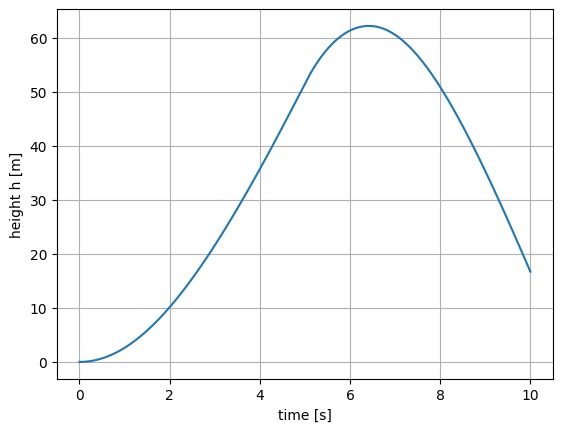

In [139]:
# Create a simulation
from matplotlib import pyplot as plt
import numpy as np


T = 10.0
dt = 0.02
N = int(T/dt)

xk = DM([0,0,1])
p_val = DM([0.02, 1e-4])

traj = []
for k in range(N):
    t= k*dt

    traj.append([t, float(xk[0]), float(xk[1]), float(xk[2])])

    if t < 5.0:
        uk = DM([15.0])
    else:
        uk = DM([0.0])
    
    xk = step(x=xk, u=uk, p=p_val, dt=dt)['xf']
traj.append([T, float(xk[0]), float(xk[1]), float(xk[2])])
traj = np.array(traj)

print(traj)

plt.figure()
plt.plot(traj[:, 0], traj[:, 1])
plt.xlabel('time [s]')
plt.ylabel('height h [m]')
plt.grid(True)
plt.show()
    